In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# Cargar datos con régimen
daily = pd.read_csv("../data/processed/eurusd_con_regimen.csv",
                    index_col=0, parse_dates=True)

print(f"\nDatos cargados: {daily.shape}")
print(f"Período: {daily.index[0].date()} → {daily.index[-1].date()}")

PyTorch: 2.11.0+cpu
Dispositivo: CPU

Datos cargados: (4031, 38)
Período: 2010-10-08 → 2026-04-03


In [3]:
# NeuralForecast requiere columnas: unique_id, ds, y
df_nf = pd.DataFrame({
    'unique_id': 'EURUSD',
    'ds': daily.index,
    'y': daily['Close'].values
})

print(f"Shape: {df_nf.shape}")
print(df_nf.tail(3))

# Parámetros del modelo
HORIZON = 5        # predecir 5 días hacia adelante
INPUT_SIZE = 60    # usar 60 días de historia

# Split train/test — últimos 252 días (1 año) para test
split_date = df_nf['ds'].iloc[-252]
train = df_nf[df_nf['ds'] < split_date]
test = df_nf[df_nf['ds'] >= split_date]

print(f"\nTrain: {len(train)} filas hasta {train['ds'].iloc[-1].date()}")
print(f"Test:  {len(test)} filas desde {test['ds'].iloc[0].date()}")

Task was destroyed but it is pending!
source_traceback: Object created at (most recent call last):
  File "C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1002, in _bootstrap
    self._bootstrap_inner()
  File "C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\mauri\Documents\kronos-trading-system\kronos_env\Lib\site-packages\ipykernel\subshell.py", line 38, in run
    super().run()
  File "C:\Users\mauri\Documents\kronos-trading-system\kronos_env\Lib\site-packages\ipykernel\thread.py", line 24, in run
    self.io_loop.start()
  File "C:\Users\mauri\Documents\kronos-trading-system\kronos_env\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 608, in run_forever
    self._run_once()
  File "C:\Users\mauri\AppData\Local\Progr

Shape: (4031, 3)
     unique_id         ds         y
4028    EURUSD 2026-04-01  1.157421
4029    EURUSD 2026-04-02  1.159057
4030    EURUSD 2026-04-03  1.152871

Train: 3779 filas hasta 2025-04-10
Test:  252 filas desde 2025-04-11


In [4]:
# Definir y entrenar PatchTST
model = PatchTST(
    h=HORIZON,
    input_size=INPUT_SIZE,
    patch_len=16,
    stride=8,
    max_steps=100,
    batch_size=32,
    learning_rate=1e-4,
)

nf = NeuralForecast(models=[model], freq='B')

print("Entrenando PatchTST...")
nf.fit(df=train)
print("Entrenamiento completado.")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Entrenando PatchTST...



  | Name         | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss         | MAE               | 0      | train | 0    
1 | padder_train | ConstantPad1d     | 0      | train | 0    
2 | scaler       | TemporalNorm      | 0      | train | 0    
3 | model        | PatchTST_backbone | 405 K  | train | 0    
-------------------------------------------------------------------
404 K     Trainable params
3         Non-trainable params
405 K     Total params
1.620     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_steps=100` reached.


Entrenamiento completado.


In [5]:
# Generar predicciones
predicciones = nf.predict()
print("Predicciones generadas:")
print(predicciones.tail(10))

# Evaluar en test
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Alinear predicciones con valores reales
pred_df = predicciones.reset_index(drop=True)
pred_df.columns = ['unique_id', 'ds', 'PatchTST']

# Merge con test
test_eval = test.copy().reset_index(drop=True)
eval_df = pd.merge(test_eval, pred_df, on=['unique_id', 'ds'], how='inner')

if len(eval_df) > 0:
    mae = mean_absolute_error(eval_df['y'], eval_df['PatchTST'])
    rmse = mean_squared_error(eval_df['y'], eval_df['PatchTST']) ** 0.5
    print(f"\nMétricas en test:")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")
else:
    print("\nPredicciones fuera de muestra — mostrando valores predichos:")
    print(predicciones)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |                                                                                                 …

Predicciones generadas:
  unique_id         ds  PatchTST
0    EURUSD 2025-04-11  1.094753
1    EURUSD 2025-04-14  1.095211
2    EURUSD 2025-04-15  1.096101
3    EURUSD 2025-04-16  1.095652
4    EURUSD 2025-04-17  1.096304

Métricas en test:
  MAE:  0.036998
  RMSE: 0.037248


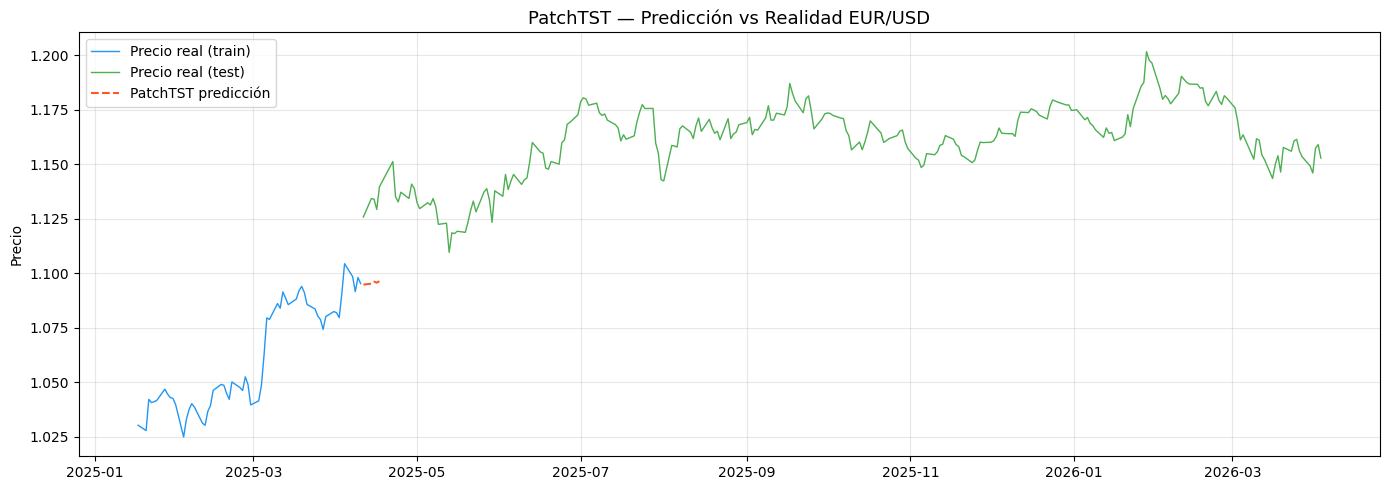

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

# Últimos 60 días de train
train_plot = train.tail(60)
ax.plot(train_plot['ds'], train_plot['y'], 
        color='#2196F3', linewidth=1, label='Precio real (train)')

# Test real
ax.plot(test['ds'], test['y'], 
        color='#4CAF50', linewidth=1, label='Precio real (test)')

# Predicciones
ax.plot(predicciones['ds'], predicciones['PatchTST'], 
        color='#FF5722', linewidth=1.5, linestyle='--', label='PatchTST predicción')

ax.set_title('PatchTST — Predicción vs Realidad EUR/USD', fontsize=13)
ax.set_ylabel('Precio')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/06_patchtst_predicciones.png', dpi=150)
plt.show()